In [1]:
import os
import sqlite3

import pandas as pd
from pycaret.classification import *

from features import label_encoder
from utilities import get_path, read_data_from_database

In [2]:
pd.options.display.max_columns = None  # Remove "dots" from display when printing dataframes

In [3]:
PATH = get_path(1)
DATABASE_FOLDER = PATH + 'data/preprocessing/BANCO_BOGOTA.db'

In [4]:
df_train = read_data_from_database(DATABASE_FOLDER, 'prep_train_data')
df_test = read_data_from_database(DATABASE_FOLDER, 'prep_test_data')

In [5]:
df_train.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,Dia,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,57,servicios,casado,bachillerato,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
1,2,37,servicios,casado,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
2,3,40,administrador negocio,casado,primaria,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
3,4,56,servicios,casado,bachillerato,0.0,0.0,1.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
4,7,25,servicios,soltero,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0


# Label encoder

In [6]:
labels_to_encoders_name = {
    'Tipo_Trabajo':'Tipo_Trabajo_ENC',
    'Estado_Civil':'Estado_Civil_ENC',
    'Educacion':'Educacion_ENC',    
    'Contacto':'Contacto_ENC',
    'Mes':'Mes_ENC',
    'Dia':'Dia_ENC',
    'Resultado_Anterior':'Resultado_Anterior_ENC'
    }

for var_encoder, encoder_name in labels_to_encoders_name.items():
    label_encoder(var_encoder, encoder_name, df_train)
    label_encoder(var_encoder, encoder_name, df_test)

In [7]:
df_train[[
    'Tipo_Trabajo', 'Tipo_Trabajo_ENC', 'Estado_Civil', 'Estado_Civil_ENC',
    'Educacion', 'Educacion_ENC', 'Contacto', 'Contacto_ENC', 'Mes', 'Mes_ENC',
    'Dia', 'Dia_ENC','Resultado_Anterior', 'Resultado_Anterior_ENC'
    ]].sample(n=10).head(10)

,Tipo_Trabajo,Tipo_Trabajo_ENC,Estado_Civil,Estado_Civil_ENC,Educacion,Educacion_ENC,Contacto,Contacto_ENC,Mes,Mes_ENC,Dia,Dia_ENC,Resultado_Anterior,Resultado_Anterior_ENC
10523,administrador negocio,0,divorciado,1,pregrado,5,celular,0,jul,3,jue,0,sin contacto,2
20856,tecnico,8,soltero,2,pregrado,5,celular,0,ago,1,jue,0,sin contacto,2
6670,servicios,7,soltero,2,bachillerato,0,telefono fijo,1,jun,4,vie,4,sin contacto,2
16744,estudiante,5,soltero,2,bachillerato,0,celular,0,abr,0,lun,1,sin contacto,2
8518,empleado,3,soltero,2,bachillerato incompleto,1,celular,0,jul,3,jue,0,sin contacto,2
22643,pensionado,6,casado,0,pregrado,5,celular,0,ago,1,jue,0,sin contacto,2
101,administrador negocio,0,casado,0,pregrado,5,telefono fijo,1,may,6,lun,1,sin contacto,2
17810,administrador negocio,0,casado,0,estudiante universitario,2,celular,0,may,6,jue,0,sin contacto,2
7785,emprendedor,4,casado,0,estudiante universitario,2,celular,0,jul,3,jue,0,sin contacto,2
9822,tecnico,8,casado,0,estudiante universitario,2,telefono fijo,1,jul,3,vie,4,sin contacto,2


# Auto Machine Learning

In [8]:
df_new = df_train[[
    # 'Edad', 'Tipo_Trabajo_ENC', 'Estado_Civil_ENC', 'Educacion_ENC', 
    # 'mora', 'Vivienda', 'Consumo', 'Contacto_ENC', 'Mes_ENC', 'Dia_ENC', 
    # 'Campana', 'Dias_Ultima_Camp', 'No_Contactos', 'Resultado_Anterior_ENC',
    # 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
    # 'y'

    'Tipo_Trabajo_ENC', 'Estado_Civil_ENC',
    'mora', 'Vivienda', 'Consumo', 'Contacto_ENC', 
    'Dias_Ultima_Camp', 'No_Contactos',
    'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m',
    'y'
    ]].copy()

df_new.head()

,Tipo_Trabajo_ENC,Estado_Civil_ENC,mora,Vivienda,Consumo,Contacto_ENC,Dias_Ultima_Camp,No_Contactos,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,y
0,7,0,0.0,0.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
1,7,0,0.0,1.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
2,0,0,0.0,0.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
3,7,0,0.0,0.0,1.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
4,7,2,0.0,1.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0


In [9]:
data = df_new.sample(frac=0.8, random_state=0)
data_unseen = df_train.drop(data.index)

In [10]:
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print(f'Datos para modelar: {data.shape}; y datos para predecir: {data_unseen.shape}')

Datos para modelar: (18479, 13); y datos para predecir: (4620, 28)


In [11]:
model_setup = setup(data=data, target='y')

,Description,Value
0,Session id,3386
1,Target,y
2,Target type,Binary
3,Original data shape,"(18479, 13)"
4,Transformed data shape,"(18479, 13)"
5,Transformed train set shape,"(12935, 13)"
6,Transformed test set shape,"(5544, 13)"
7,Numeric features,12
8,Preprocess,True
9,Imputation type,simple


In [12]:
models()  # Modelos suportados

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [13]:
best_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8979,0.7861,0.2248,0.6373,0.3310,0.2898,0.3368,0.1030
ada,Ada Boost Classifier,0.8960,0.7779,0.1833,0.6432,0.2844,0.2471,0.3049,0.0460
catboost,CatBoost Classifier,0.8951,0.7774,0.2473,0.5878,0.3474,0.3008,0.3346,3.2770
lightgbm,Light Gradient Boosting Machine,0.8944,0.7754,0.2419,0.5796,0.3403,0.2938,0.3274,0.1030
ridge,Ridge Classifier,0.8925,0.7494,0.1199,0.6349,0.2010,0.1716,0.2427,0.0070
lr,Logistic Regression,0.8923,0.7586,0.1294,0.6202,0.2131,0.1815,0.2479,0.4940
xgboost,Extreme Gradient Boosting,0.8917,0.7510,0.2582,0.5480,0.3506,0.2999,0.3254,0.0340
knn,K Neighbors Classifier,0.8906,0.7086,0.2772,0.5353,0.3641,0.3111,0.3318,0.3240
lda,Linear Discriminant Analysis,0.8881,0.7494,0.2644,0.5146,0.3480,0.2938,0.3139,0.0090
dummy,Dummy Classifier,0.8865,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0090


In [14]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8988,0.7786,0.1905,0.7000,0.2995,0.2637,0.3300
1,0.8957,0.7530,0.1973,0.6304,0.3005,0.2605,0.3127
2,0.9034,0.7884,0.2313,0.7391,0.3523,0.3153,0.3785
3,0.8872,0.7799,0.1361,0.5128,0.2151,0.1758,0.2218
4,0.8910,0.7711,0.1293,0.5938,0.2123,0.1789,0.2409
5,0.8956,0.7537,0.1644,0.6486,0.2623,0.2270,0.2905
6,0.9033,0.7814,0.2466,0.7059,0.3655,0.3261,0.3797
7,0.8910,0.7876,0.1429,0.5833,0.2295,0.1934,0.2504
8,0.8987,0.8154,0.2041,0.6818,0.3141,0.2762,0.3359


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=3386)


In [15]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8988,0.7786,0.1905,0.7000,0.2995,0.2637,0.3300
1,0.8957,0.7530,0.1973,0.6304,0.3005,0.2605,0.3127
2,0.9034,0.7884,0.2313,0.7391,0.3523,0.3153,0.3785
3,0.8872,0.7799,0.1361,0.5128,0.2151,0.1758,0.2218
4,0.8910,0.7711,0.1293,0.5938,0.2123,0.1789,0.2409
5,0.8956,0.7537,0.1644,0.6486,0.2623,0.2270,0.2905
6,0.9033,0.7814,0.2466,0.7059,0.3655,0.3261,0.3797
7,0.8910,0.7876,0.1429,0.5833,0.2295,0.1934,0.2504
8,0.8987,0.8154,0.2041,0.6818,0.3141,0.2762,0.3359


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=3386)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9003,0.7648,0.1837,0.7500,0.2951,0.2621,0.3393
1,0.8988,0.7469,0.1905,0.7000,0.2995,0.2637,0.3300
2,0.9034,0.7693,0.2109,0.7750,0.3316,0.2974,0.3723
3,0.8903,0.7796,0.1088,0.5926,0.1839,0.1541,0.2204
4,0.8910,0.7767,0.1020,0.6250,0.1754,0.1483,0.2215
5,0.8971,0.7425,0.1575,0.6970,0.2570,0.2247,0.2987
6,0.9018,0.7701,0.2055,0.7317,0.3209,0.2855,0.3538
7,0.8956,0.7625,0.1361,0.7143,0.2286,0.1994,0.2815
8,0.9018,0.8146,0.1769,0.8125,0.2905,0.2604,0.3507


Fitting 10 folds for each of 10 candidates, totalling 100 fits


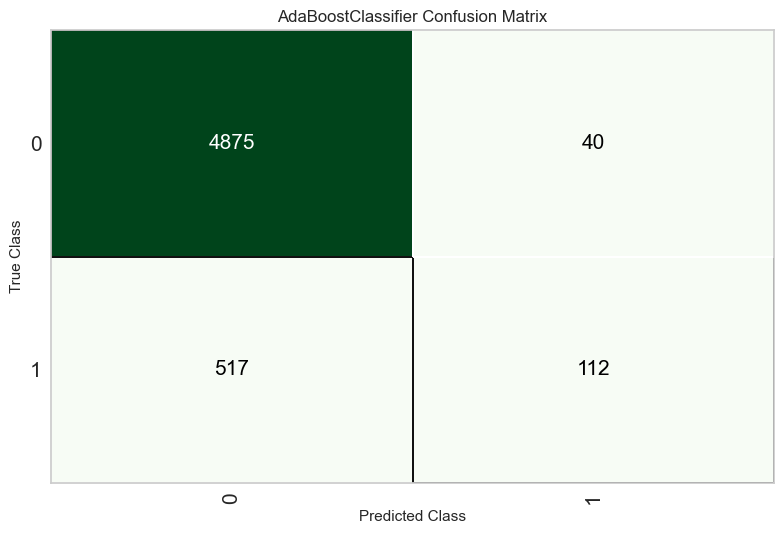

In [16]:
tuned_ada = tune_model(ada)
plot_model(tuned_ada, plot='confusion_matrix')

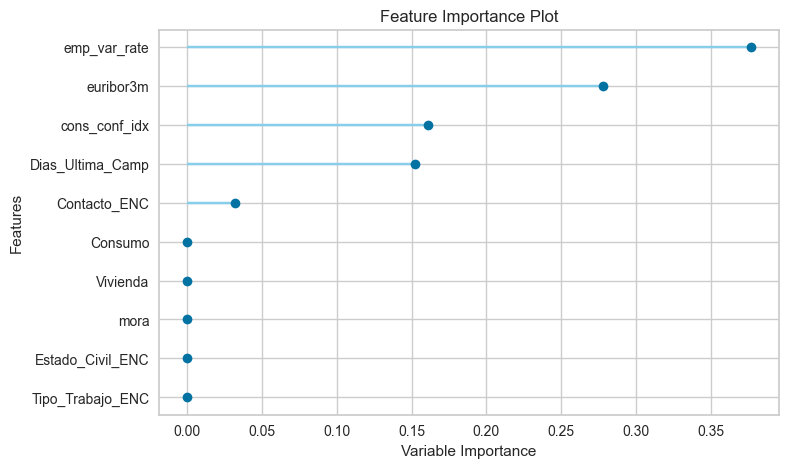

In [17]:
plot_model(tuned_ada, plot='feature')

In [18]:
unseen_predictions = predict_model(tuned_ada, data=data_unseen)
unseen_predictions[['y', 'prediction_label', 'prediction_score']].sample(n=25).head(25)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.9019,0.7879,0.1582,0.6724,0.2562,0.2246,0.2940


,y,prediction_label,prediction_score
1804,0,0,0.8002
2685,0,0,0.8191
4306,0,1,0.5730
4445,0,0,0.6295
1579,0,0,0.8191
494,0,0,0.8372
2688,0,0,0.8191
1602,1,0,0.8191
665,1,0,0.8372
3546,0,0,0.7421


In [19]:
final_ada = finalize_model(tuned_ada)
print(final_ada)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Tipo_Trabajo_ENC',
                                             'Estado_Civil_ENC', 'mora',
                                             'Vivienda', 'Consumo',
                                             'Contacto_ENC', 'Dias_Ultima_Camp',
                                             'No_Contactos', 'emp_var_rate',
                                             'cons_price_idx', 'cons_conf_idx',
                                             'euribor3m'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=...
                ('categorical_imputer',
                 TransformerWrapper(exclude=None, include=[],
                                   

# Save model

In [20]:
save_model(final_ada, PATH + 'data/salida/ADA_model_02-05-2024')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Tipo_Trabajo_ENC',
                                              'Estado_Civil_ENC', 'mora',
                                              'Vivienda', 'Consumo',
                                              'Contacto_ENC', 'Dias_Ultima_Camp',
                                              'No_Contactos', 'emp_var_rate',
                                              'cons_price_idx', 'cons_conf_idx',
                                              'euribor3m'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=...
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=[],
                    

# Deploy

In [21]:
ada_model = load_model(PATH + 'data/salida/ADA_model_02-05-2024')

Transformation Pipeline and Model Successfully Loaded


In [22]:
df_implement = predict_model(ada_model, data=df_test)
df_implement = df_implement.rename({
    'prediction_label':'y'
    }, axis=1)

In [23]:
df_implement.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,...,nr_employed,Tipo_Trabajo_ENC,Estado_Civil_ENC,Educacion_ENC,Contacto_ENC,Mes_ENC,Dia_ENC,Resultado_Anterior_ENC,y,prediction_score
0,5,41,empleado,casado,pregrado,0.0,0.0,0.0,telefono fijo,may,...,5191,3,0,5,1,6,1,2,0,0.8392
1,6,24,tecnico,soltero,estudiante universitario,0.0,1.0,0.0,telefono fijo,may,...,5191,8,2,2,1,6,1,2,0,0.8392
2,11,57,ama de casa,divorciado,preescolar,0.0,1.0,0.0,telefono fijo,may,...,5191,1,1,4,1,6,1,2,0,0.8392
3,13,54,pensionado,casado,bachillerato incompleto,0.0,1.0,1.0,telefono fijo,may,...,5191,6,0,1,1,6,1,2,0,0.8392
4,16,39,vive de los arriendos,soltero,bachillerato incompleto,0.0,0.0,0.0,telefono fijo,may,...,5191,10,2,1,1,6,1,2,0,0.8392


# Save data

In [24]:
# Load to DataBase
try:
    # Create a connection to the SQLite database
    conn = sqlite3.connect(os.path.join(PATH, 'data', 'preprocessing', 'BANCO_BOGOTA.db'))

    df_implement.to_sql(
    'Result_TechnicalTest_DS_AMT', conn, index=False, if_exists='replace'    
    )
    # Commit changes
    conn.commit()
    print('Data loaded successfully to the database.')
except Exception as e:
    print(f'An error occurred while loading data to the database: {str(e)}')
    if conn is not None:
        conn.rollback()
finally:
    # Close connection
    if conn is not None:
        conn.close()
        print('Database connection closed.')

Data loaded successfully to the database.
Database connection closed.


In [25]:
del df_train, df_test, df_new, df_implement  # Delete variables to free memory